Sedang memuat dan memproses gambar...
Total gambar berhasil dimuat: 4317
Bentuk Vektor Fitur (Jumlah Data, Fitur): (4317, 12288)

Jumlah Data Latih (Train): 3453
Jumlah Data Uji (Test)  : 864

Sedang melatih model Multi-Layer Perceptron (MLP)...
Iteration 1, loss = 3.03760210
Iteration 2, loss = 1.52304853
Iteration 3, loss = 1.39306203
Iteration 4, loss = 1.29142345
Iteration 5, loss = 1.24478451
Iteration 6, loss = 1.21650067
Iteration 7, loss = 1.18201787
Iteration 8, loss = 1.14419316
Iteration 9, loss = 1.12995342
Iteration 10, loss = 1.09663128
Iteration 11, loss = 1.11210518
Iteration 12, loss = 1.05881641
Iteration 13, loss = 1.04173267
Iteration 14, loss = 1.00652306
Iteration 15, loss = 1.02456881
Iteration 16, loss = 0.99661199
Iteration 17, loss = 0.97988483
Iteration 18, loss = 0.99846864
Iteration 19, loss = 0.96054548
Iteration 20, loss = 0.90296918
Iteration 21, loss = 0.94991126
Iteration 22, loss = 0.92458452
Iteration 23, loss = 0.86932563
Iteration 24, loss = 0.8651

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Pelatihan model selesai!

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       daisy     0.5467    0.2680    0.3596       153
   dandelion     0.4523    0.5190    0.4834       210
        rose     0.3702    0.4268    0.3964       157
   sunflower     0.6569    0.4558    0.5382       147
       tulip     0.3925    0.5279    0.4502       197

    accuracy                         0.4491       864
   macro avg     0.4837    0.4395    0.4456       864
weighted avg     0.4752    0.4491    0.4474       864



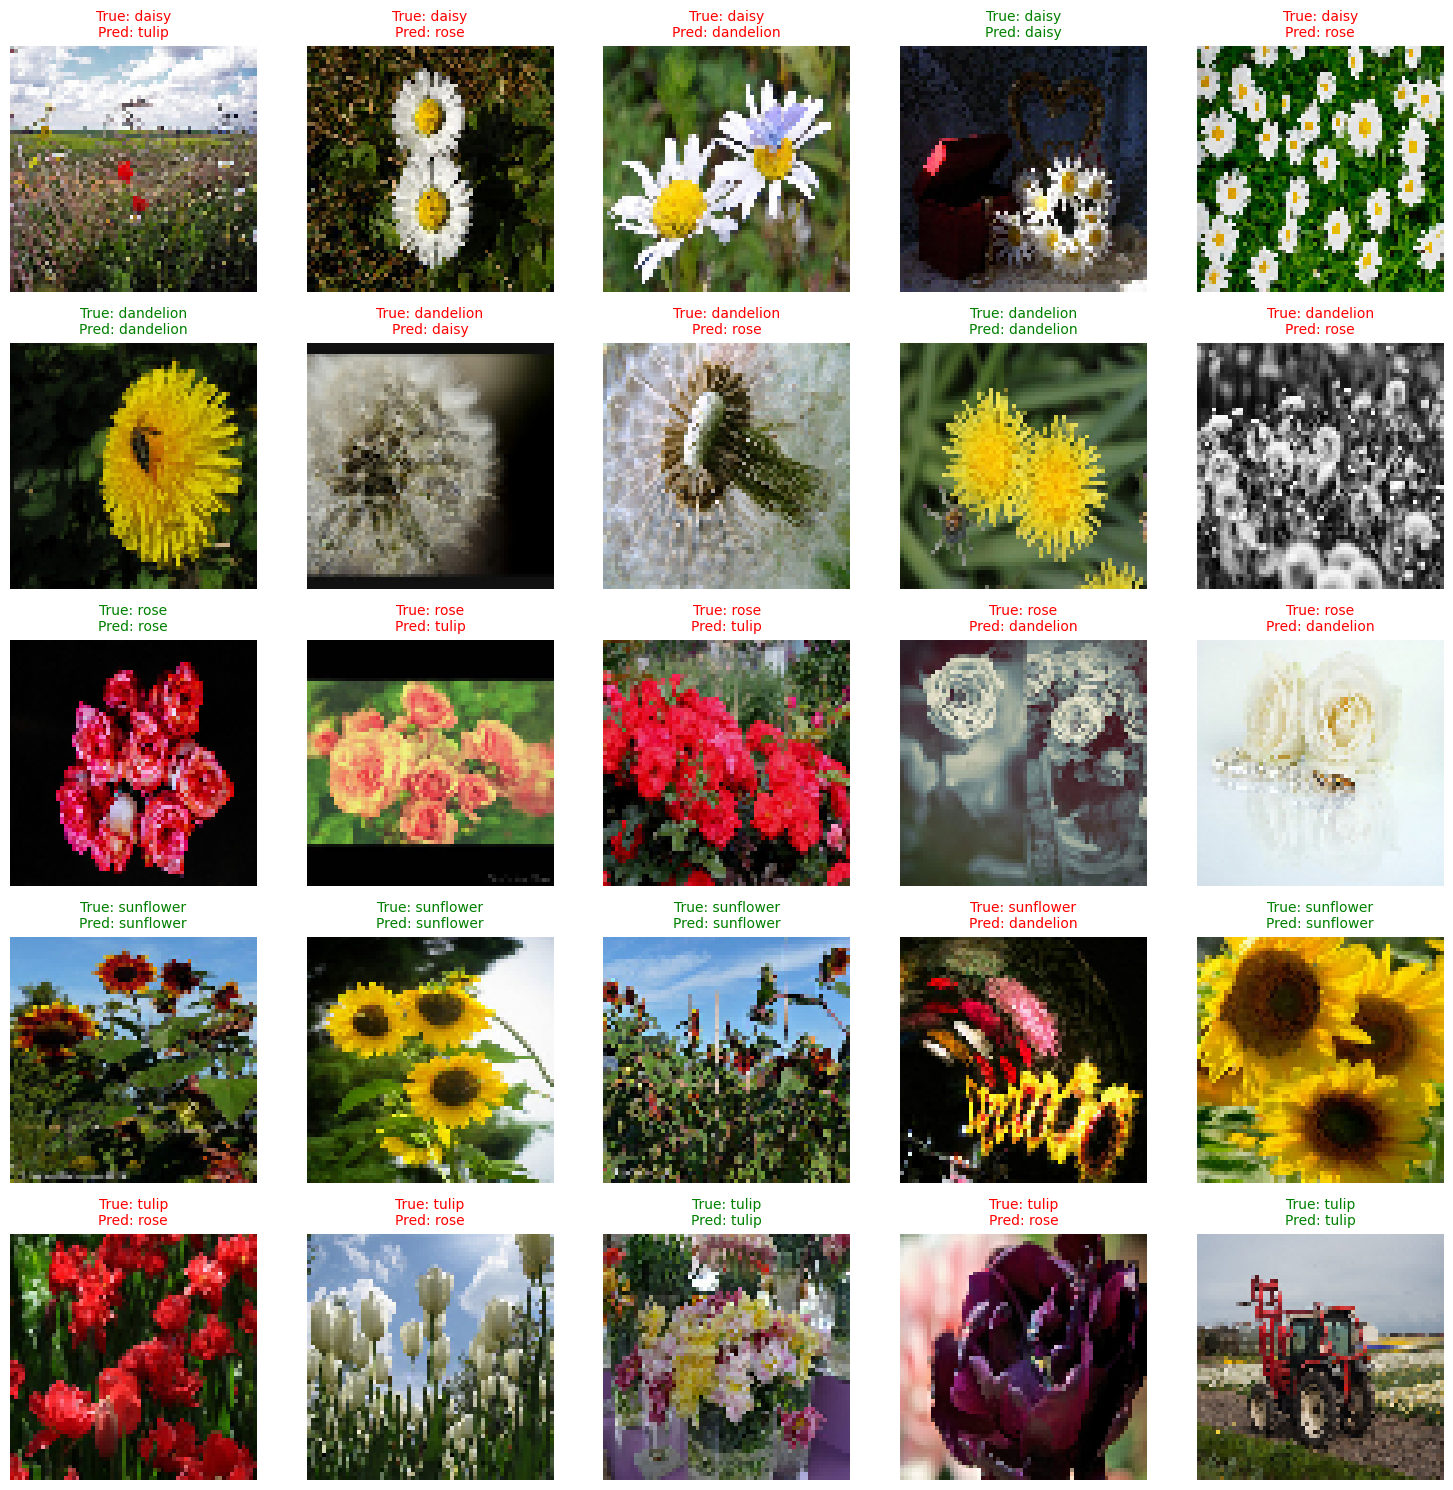

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# ==========================================
# 1. PARAMETER & KONFIGURASI
# ==========================================
# Ganti dengan NIM Anda (Wajib sesuai instruksi soal)
NIM = 24146096# <--- UBAH INI SESUAI NIM ANDA

# Nama folder dataset di VS Code Anda
DATASET_PATH = "flowers"  

# Ukuran gambar yang diseragamkan (64x64 piksel agar proses training tidak terlalu berat)
IMG_SIZE = (64, 64)

# Daftar 5 kelas bunga sesuai dataset
CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Set random seed untuk hasil numerik numpy yang konsisten
np.random.seed(NIM)

# ==========================================
# 2. LOAD DATASET & PREPROCESSING
# ==========================================
X = []
y = []

print("Sedang memuat dan memproses gambar...")

for label_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(DATASET_PATH, class_name)
    
    # Cek apakah folder kelas ada
    if not os.path.exists(folder_path):
        print(f"Peringatan: Folder '{folder_path}' tidak ditemukan!")
        continue
        
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        # Baca gambar
        img = cv2.imread(img_path)
        
        if img is not None:
            # 1. Resize gambar ke 64x64
            img = cv2.resize(img, IMG_SIZE)
            
            # 2. Konversi warna dari BGR (OpenCV default) ke RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # 3. Flatten (ubah matriks 2D/3D jadi vektor 1D) & Normalisasi piksel (0-1)
            X.append(img.flatten() / 255.0)
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print(f"Total gambar berhasil dimuat: {len(X)}")
print(f"Bentuk Vektor Fitur (Jumlah Data, Fitur): {X.shape}\n")

# ==========================================
# 3. SPLIT DATASET (80% Train, 20% Test)
# ==========================================
# Menggunakan NIM Anda sebagai random_state sesuai instruksi UAS
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=NIM, 
    stratify=y
)

print(f"Jumlah Data Latih (Train): {len(X_train)}")
print(f"Jumlah Data Uji (Test)  : {len(X_test)}\n")

# ==========================================
# 4. TRAINING MODEL MLP (Multilayer Perceptron)
# ==========================================
print("Sedang melatih model Multi-Layer Perceptron (MLP)...")

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 Hidden Layer: 128 & 64 neuron
    activation='relu',             # Fungsi aktivasi ReLu
    solver='adam',                 # Optimizer Adam
    max_iter=300,                  # Maksimal iterasi (epoch)
    random_state=NIM,              # Menggunakan NIM
    verbose=True                   # Menampilkan proses training tiap epoch
)

model.fit(X_train, y_train)
print("Pelatihan model selesai!\n")

# ==========================================
# 5. EVALUASI MODEL
# ==========================================
y_pred = model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
# Wajib menggunakan digits=4 sesuai instruksi soal
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

# ==========================================
# 6. VISUALISASI 25 GAMBAR PREDIKSI
# ==========================================
# Mengambil 5 gambar acak per kelas (Total 25 gambar)
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i, class_name in enumerate(CLASSES):
    # Cari indeks data uji yang memiliki kelas ini
    indices = np.where(y_test == i)[0]
    
    # Pilih 5 gambar secara acak
    selected_indices = np.random.choice(indices, 5, replace=False)
    
    for j, idx in enumerate(selected_indices):
        # Kembalikan bentuk vektor 1D menjadi matriks gambar 3D (64x64x3) untuk ditampilkan
        img_reshaped = X_test[idx].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)
        actual_label = CLASSES[y_test[idx]]
        pred_label = CLASSES[y_pred[idx]]
        
        ax = axes[i, j]
        ax.imshow(img_reshaped)
        ax.axis('off')
        
        # Warna hijau jika prediksi benar, merah jika salah
        color = 'green' if actual_label == pred_label else 'red'
        ax.set_title(f"True: {actual_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.tight_layout()
plt.show()